# WASSA 2024 Shared Task

This notebook summarizes the **WASSA 2024 Shared Task on Empathy and Personality Detection in Interactions**
* [Findings paper](https://aclanthology.org/2024.wassa-1.30.pdf)
* [CodaLab competition #18810](https://codalab.lisn.upsaclay.fr/competitions/18810)

## Introduction

Participants (crowd workers) **read news articles** (often about harm to a person, group, or nature), and **wrote a short essay** (300–800 characters) about how the article made them feel. They then self-reported their **empathy and distress** (Batson scale), filled out **personality** (Big Five), IRI, and demographic surveys. Participants then had a **conversation** about the article with a partner (person or an AI).

Every conversation turn (≥10 turns/person in train/dev, 15 in test) was later **third-party annotated** for empathy and emotion. The shared task asks teams to **predict** these human signals from text.

It is a new, unpublished extension of the WASSA 2023 dataset (originally from Omitaomu et al., 2022), with two new components this year: participants rated their conversational **partner's** empathy, and some conversations were with a **conversational AI** system.

### The four tasks

| Track | Name | Source | Predict | Output |
|---|---|---|---|---|
| 1 | **CONV-Dialog** | whole dialog | perceived empathy of the partner | 1 score (1–7) |
| 2 | **CONV-Turn** | each chat turn | emotion polarity, emotion intensity, empathy | 3 scores |
| 3 | **EMP** | each essay | empathic concern, personal distress | 2 scores (1–7) |
| 4 | **PER** | each essay | Big Five / OCEAN personality | 5 scores |

### Evaluation

Everything is scored with the **Pearson product-moment correlation** (−1 to 1; higher = predictions track the true values better). For tasks with multiple targets, the official metric is the **average** of the per-target correlations.

**Note:** The dataset should live in the **`data/wassa2024/`** folder of this repo, one comma-separated file per task and split.

In [3]:
from pathlib import Path
import pandas as pd
import plotnine as p9

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

/tmp/ipykernel_1288515/934847806.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Prepare data

In [2]:
from pathlib import Path
import pandas as pd

datafolder = Path("../../data/wassa2024")

turns = pd.read_csv(datafolder / "trac2_CONVT_train.csv", escapechar="\\")    # turn-level annotations
dialog = pd.read_csv(datafolder / "trac1_CONVD_train.csv", escapechar="\\")   # post-conversation perceived empathy
dialog = dialog.rename(
    columns={
        "person_id_1": "person_id",
        "this_persons_perceived_empathy_of_other_person": "perceived_empathy_of_other_person",
    }
)
essays = pd.read_csv(datafolder / "trac3_EMP_train.csv", escapechar="\\")     # essays + state empathy/distress
persons = pd.read_csv(datafolder / "trac4_PER_train.csv", escapechar="\\")    # per-person traits/demographics
persons = persons.drop(columns=["id"])

# 1. Conversation turns — one row per turn, with all turn-level annotations.
conversations = pd.DataFrame(
    {
        "conversation_id": turns["conversation_id"],
        "speaker_id": turns["person_id_1"].where(turns["speaker"].eq("Person 1"), turns["person_id_2"]),
        "turn_id": turns["turn_id"],
        "text": turns["text"],
        "emotion": turns["Emotion"],
        "emotional_polarity": turns["EmotionalPolarity"],
        "empathy": turns["Empathy"],
        "self_disclosure": turns["SelfDisclosure"],
    }
)
# (conversation_id, turn_id) uniquely identifies a turn — combine them into a single key.
conversations["message_id"] = conversations["conversation_id"].astype(str) + "_" + conversations["turn_id"].astype(str)
# (conversation_id, speaker_id) identifies a person within one conversation
conversations["conv_speaker"] = conversations["conversation_id"].astype(str) + "_" + conversations["speaker_id"].astype(str)

# 2. Surveys — per-person self-report gathered AFTER each conversation (perceived empathy
# of the partner) joined to that person's stable self-reported traits/demographics.
surveys = pd.merge(
    dialog, 
    persons, 
    on="person_id", 
    how="left"
)
surveys = surveys.rename(columns={"personality_openess": "personality_openness"})

# 3. Essays — each essay, the participants who wrote it, and the article they responded to.
essays = essays.rename(
    columns={
        "person_essay": "essay",
        "person_empathy": "essay_empathy",
        "person_distress": "essay_distress",
    }
)
essays = essays[["article_id", "person_id", "conversation_id", "essay", "essay_empathy", "essay_distress"]]

for name, df in [
    ("conversations", conversations),
    ("surveys", surveys),
    ("essays", essays)
]:
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} cols")
    print("Columns:", list(df.columns))
    print("-" * 40)

display(conversations.head())
display(surveys.head())
display(essays.head())

conversations: 11166 rows x 10 cols
Columns: ['conversation_id', 'speaker_id', 'turn_id', 'text', 'emotion', 'emotional_polarity', 'empathy', 'self_disclosure', 'message_id', 'conv_speaker']
----------------------------------------
surveys: 1000 rows x 19 cols
Columns: ['id', 'conversation_id', 'article_id', 'person_id', 'perceived_empathy_of_other_person', 'gender', 'education', 'race', 'age', 'income', 'iri_perspective_taking', 'iri_personal_distress', 'iri_fantasy', 'iri_empathatic_concern', 'personality_openness', 'personality_conscientiousness', 'personality_extraversion', 'personality_agreeableness', 'personality_stability']
----------------------------------------
essays: 1000 rows x 6 cols
Columns: ['article_id', 'person_id', 'conversation_id', 'essay', 'essay_empathy', 'essay_distress']
----------------------------------------


,conversation_id,speaker_id,turn_id,text,emotion,emotional_polarity,empathy,self_disclosure,message_id,conv_speaker
0,1,p019,0,what did you think about this article,0.6667,1.0,0.6667,1.0000,1_0,1_p019
1,1,p012,1,"It's definitely really sad to read, considerin...",3.0000,2.0,4.3333,2.0000,1_1,1_p012
2,1,p019,2,I think it's super sad... they seem to never c...,3.6667,2.0,4.6667,2.6667,1_2,1_p019
3,1,p012,3,I can't imagine just living in an area that is...,3.0000,2.0,4.6667,3.3333,1_3,1_p012
4,1,p019,4,Me too.. I also can't imagine living in the po...,3.3333,2.0,4.6667,3.0000,1_4,1_p019


,id,conversation_id,article_id,person_id,perceived_empathy_of_other_person,gender,education,race,age,income,iri_perspective_taking,iri_personal_distress,iri_fantasy,iri_empathatic_concern,personality_openness,personality_conscientiousness,personality_extraversion,personality_agreeableness,personality_stability
0,1,1,35,p019,6,2,2,1,21,20000,2.714286,3.000000,3.142857,3.285714,3.00,5.00,5.00,4.00,3.5
1,2,2,35,p035,7,1,6,3,37,40000,4.857143,2.000000,3.428571,5.000000,5.50,7.00,1.00,6.50,6.0
2,3,3,35,p024,5,1,6,2,32,35000,3.428571,2.857143,2.857143,2.714286,5.00,5.50,2.00,5.50,4.5
3,4,4,35,p041,5,1,6,3,33,64000,3.714286,1.000000,2.428571,1.428571,7.00,6.50,3.50,4.50,7.0
4,5,5,35,p022,7,1,6,1,29,85000,4.642857,2.071429,4.142857,4.642857,6.75,6.75,6.75,6.75,7.0


,article_id,person_id,conversation_id,essay,essay_empathy,essay_distress
0,35,p019,1,How sad is it that this kind of pain and suffe...,3.857143,3.285714
1,35,p035,2,It breaks my heart to see people living in tho...,6.714286,6.714286
2,35,p024,3,I wonder why there aren't more people trying t...,5.857143,6.000000
3,35,p041,4,The article is kind of tragic and hits close t...,2.714286,1.000000
4,35,p022,5,"After reading the article, you can't help but ...",1.000000,1.428571


## Descriptives

Computed from the prepared tables — number of conversations and participants, participant demographics, self-reported OCEAN and IRI distributions, and turns per conversation.

In [3]:
print(f"conversations: {surveys['conversation_id'].nunique()}")
print(f"participants: {surveys['person_id'].nunique()}")

conversations \
    .groupby("conversation_id") \
    .agg({"turn_id": "count"}) \
    .rename(columns={"turn_id": "Turns per conversation"}) \
    .describe() \
    .round(2)

conversations: 500
participants: 75


,Turns per conversation
count,487.00
mean,22.93
std,4.07
min,13.00
25%,20.00
50%,22.00
75%,24.00
max,44.00


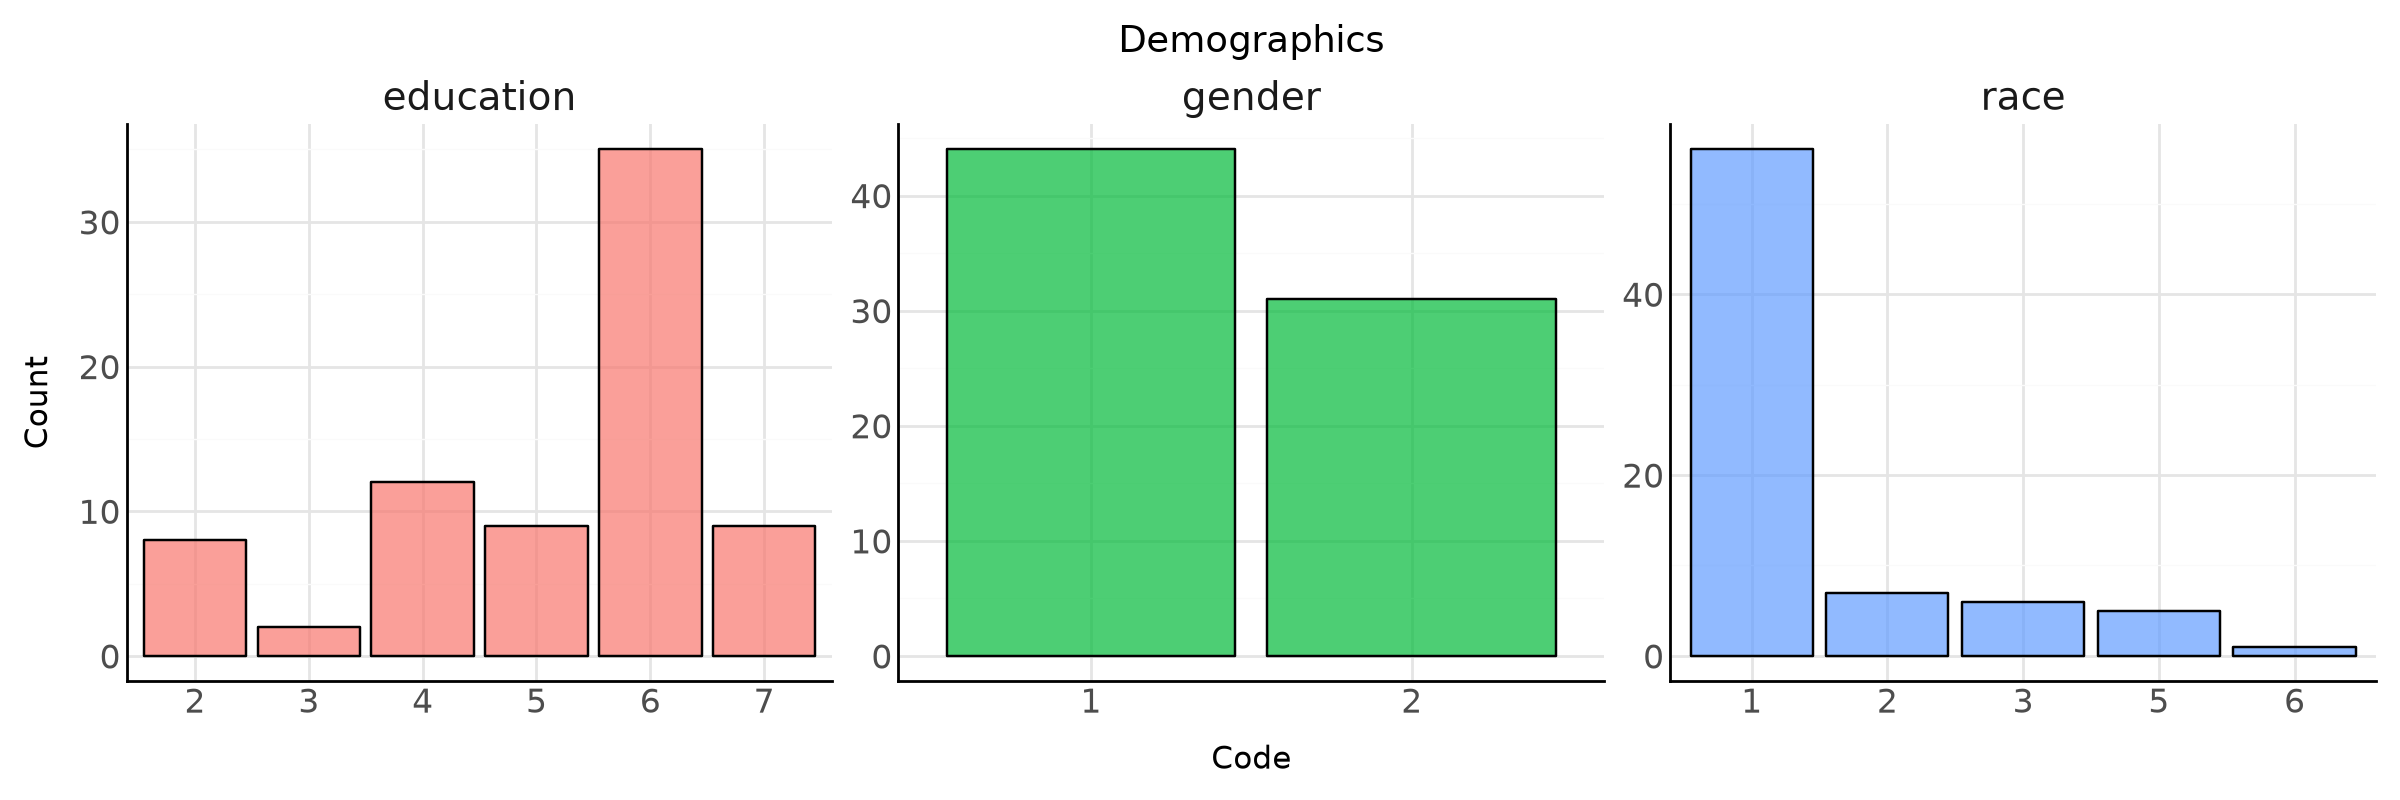

In [4]:
# Demographic distributions — categorical survey codes (one row per participant).
categorical = surveys.drop_duplicates("person_id")[["gender", "education", "race"]]
categorical = categorical.melt(var_name="variable", value_name="code")

(
    p9.ggplot(categorical, p9.aes(x="factor(code)", fill="variable")) +
    p9.geom_bar(color="black", alpha=0.7) +
    p9.facet_wrap("variable", scales="free", ncol=3) +
    p9.labs(
        title="Demographics",
        x="Code",
        y="Count",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
        legend_position="none"
    )
)

#FIXME: get codebook for variables

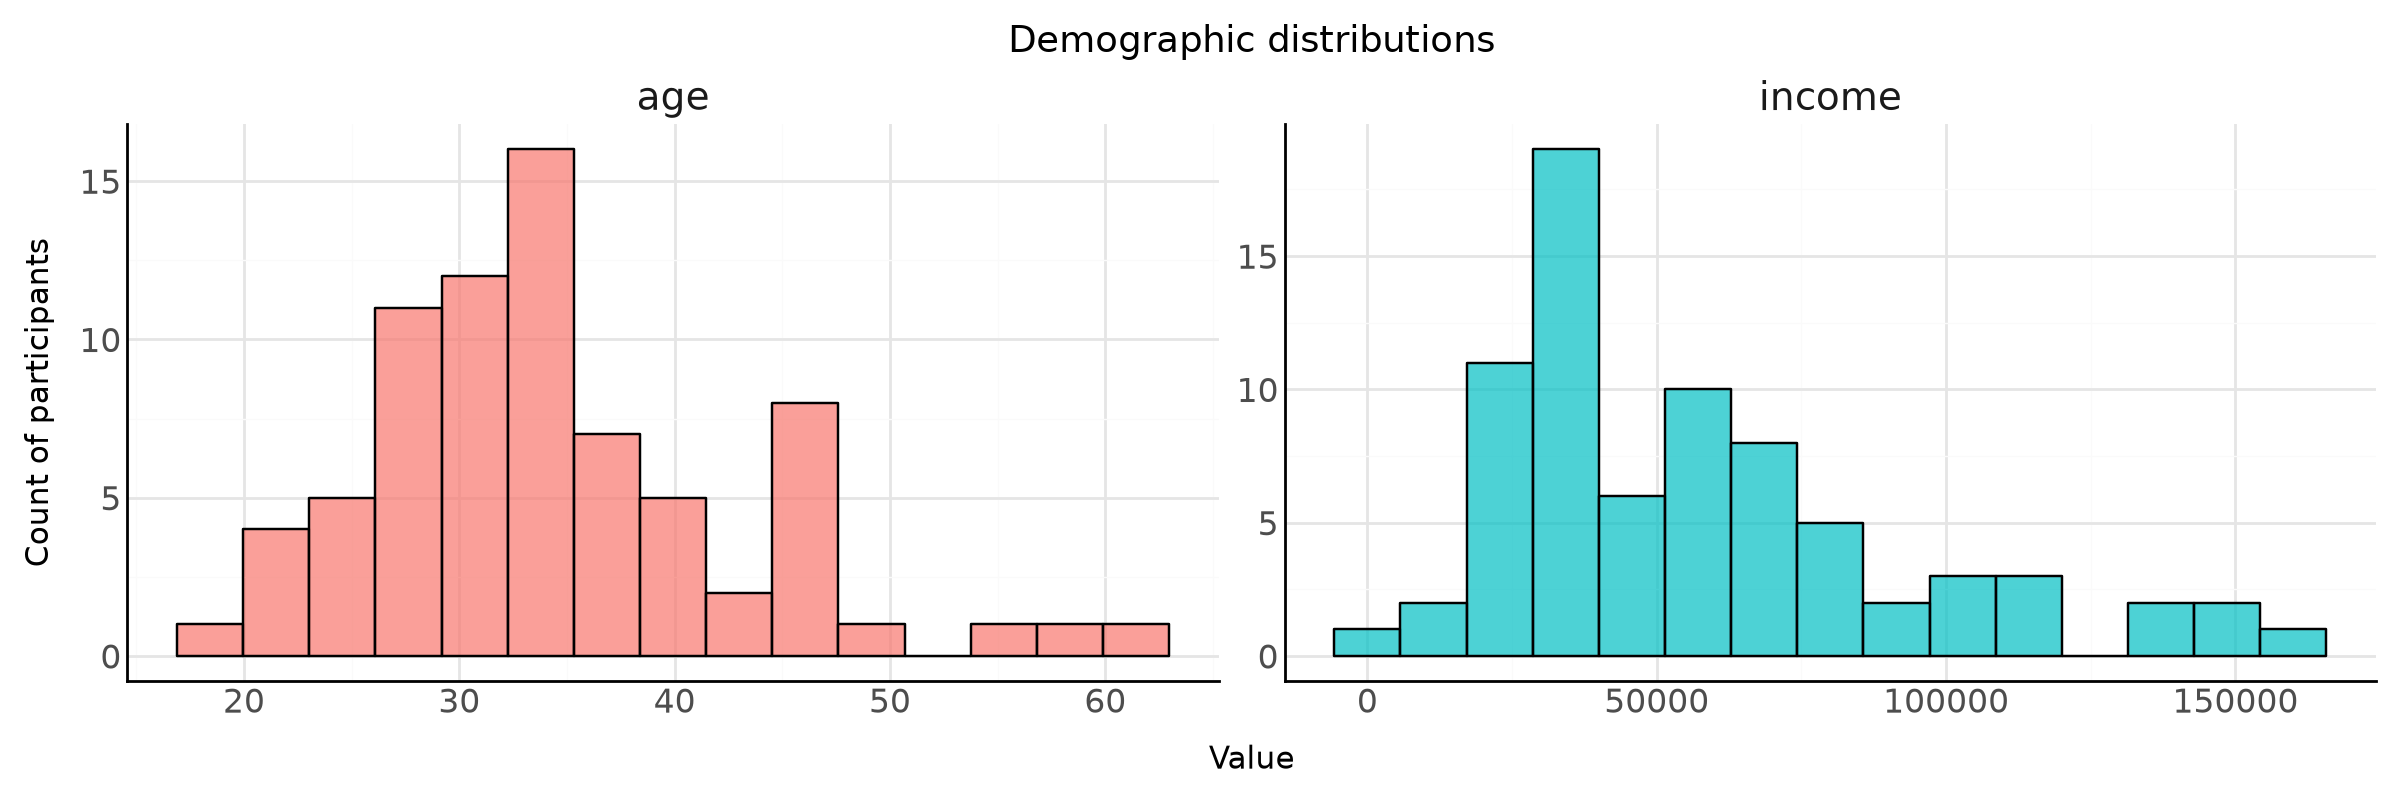

In [5]:
numerical = surveys.drop_duplicates("person_id")[["age", "income"]]
numerical = numerical.melt(var_name="variable", value_name="value")

(
    p9.ggplot(numerical, p9.aes(x="value", fill="variable")) +
    p9.geom_histogram(bins=15, color="black", alpha=0.7) +
    p9.facet_wrap("variable", scales="free", ncol=2) +
    p9.labs(
        title="Demographic distributions",
        x="Value",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        legend_position="none",
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

# mostly young adults, who have income ~50K pa.

,count,mean,std,min,25%,50%,75%,max
personality_openness,75.0,5.30,1.33,2.0,4.0,5.5,6.25,7.0
personality_conscientiousness,75.0,5.70,1.17,2.5,5.5,6.0,6.50,7.0
personality_extraversion,75.0,3.62,1.86,1.0,2.0,3.5,5.00,7.0
personality_agreeableness,75.0,5.47,1.18,2.0,4.5,5.5,6.50,7.0
personality_stability,75.0,5.02,1.59,1.0,4.0,5.5,6.00,7.0


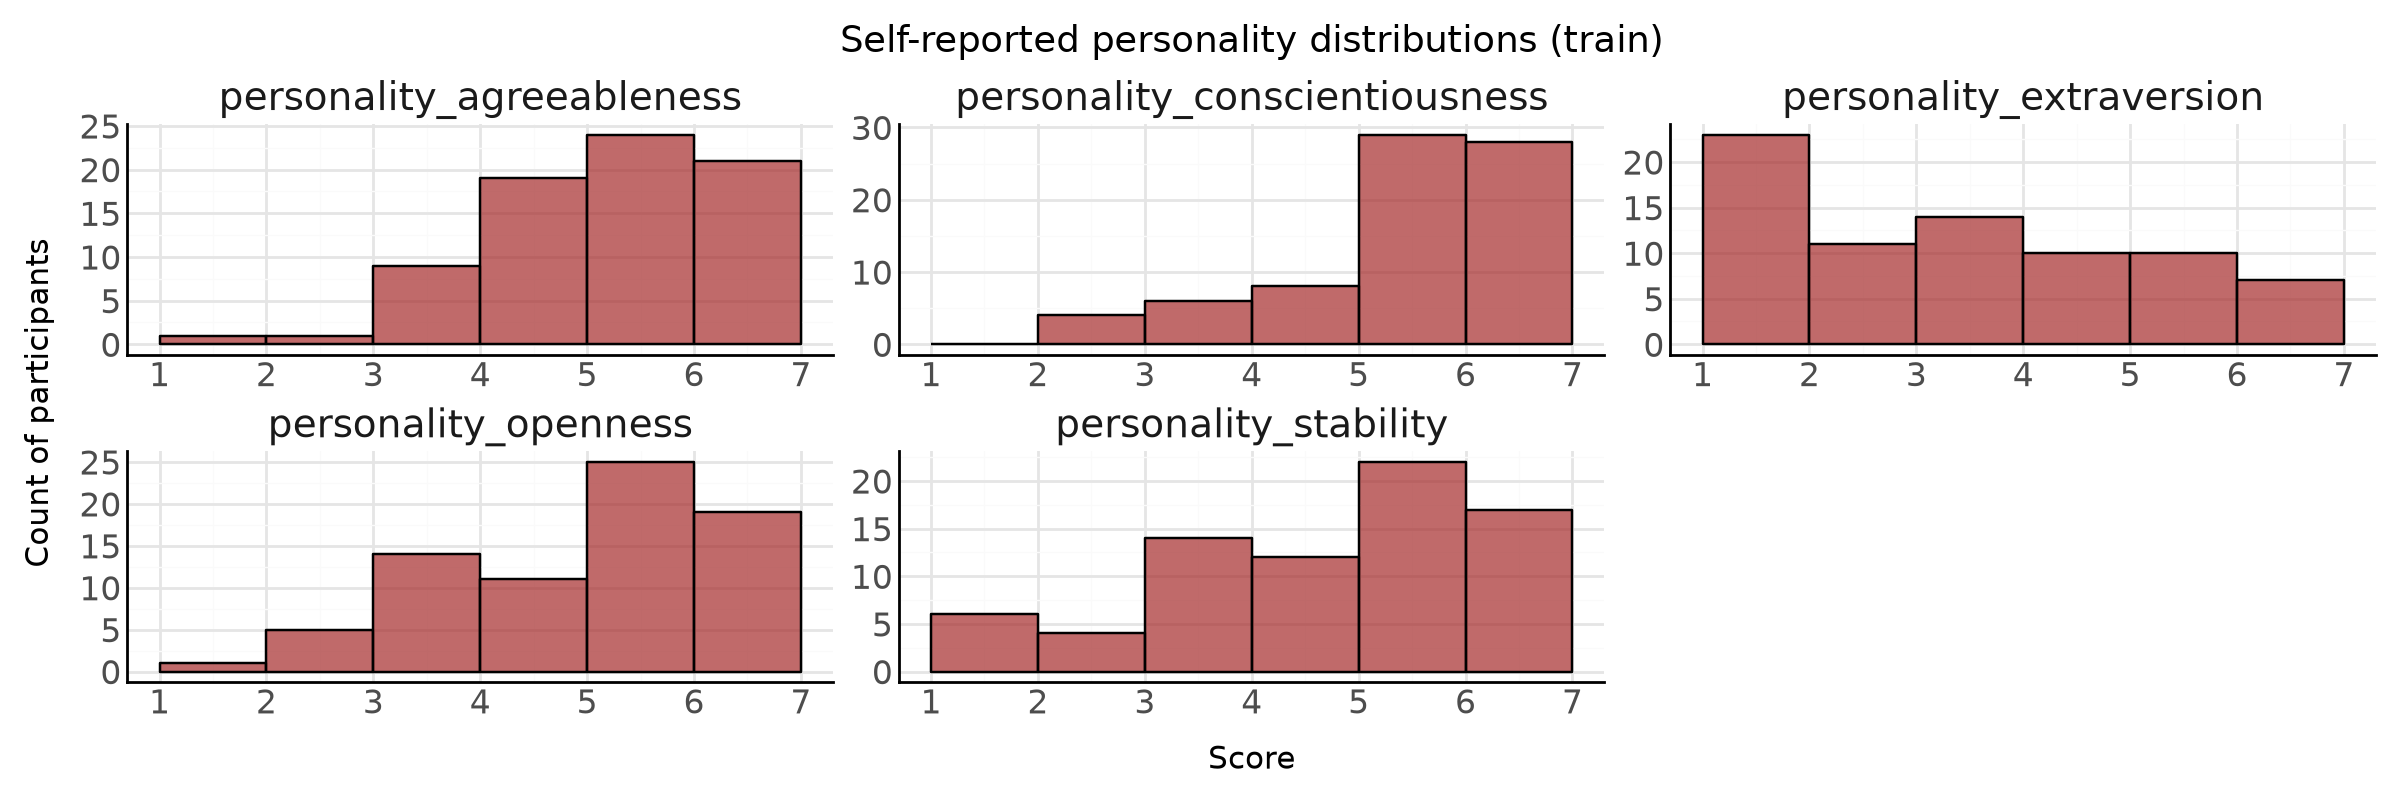

In [6]:
personality = surveys.drop_duplicates("person_id")[[
    "personality_openness",
    "personality_conscientiousness",
    "personality_extraversion",
    "personality_agreeableness",
    "personality_stability",
]]

display(personality.describe().round(2).T)

personality = personality.melt(var_name="trait", value_name="score")
(
    p9.ggplot(personality, p9.aes(x="score")) +
    p9.geom_histogram(breaks=range(1, 8), fill="brown", color="black", alpha=0.7) +
    p9.facet_wrap("trait", scales="free", ncol=3) +
    p9.scale_x_continuous(breaks=range(1, 8)) +
    p9.labs(
        title="Self-reported personality distributions (train)",
        x="Score",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 4),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

#FIXME: check how people skew in general, and then for this demographics.

,count,mean,std,min,25%,50%,75%,max
iri_perspective_taking,75.0,3.88,0.79,1.86,3.39,4.00,4.50,5.00
iri_personal_distress,75.0,2.46,0.83,1.00,1.93,2.43,2.93,4.43
iri_fantasy,75.0,3.49,0.90,1.57,2.86,3.43,4.21,5.00
iri_empathatic_concern,75.0,3.83,0.96,1.43,3.29,3.86,4.68,5.00


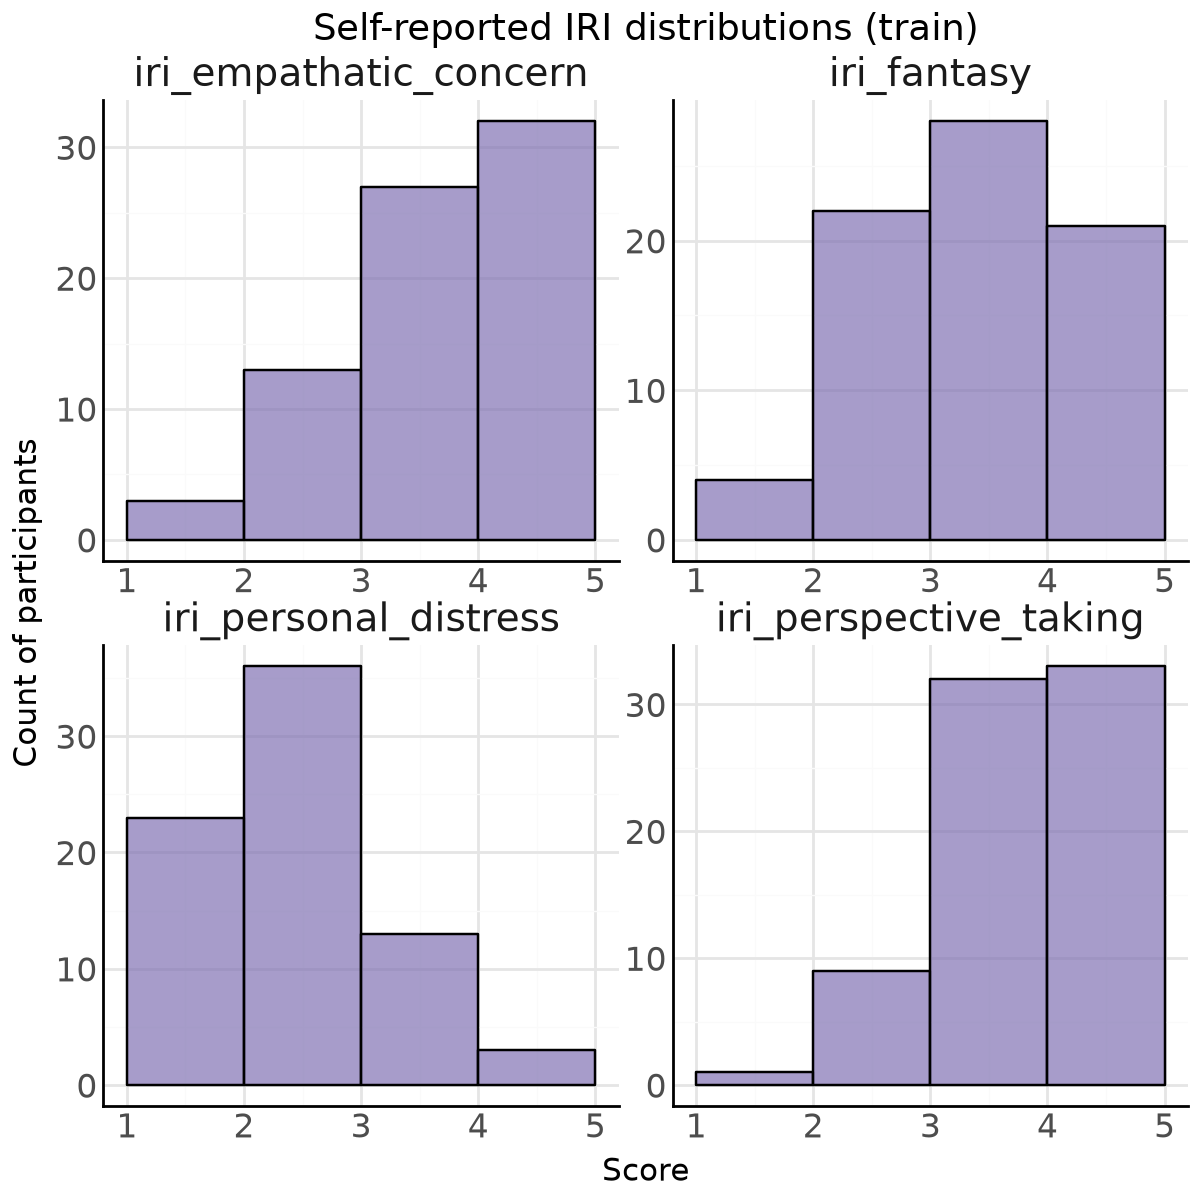

In [7]:
iri = surveys.drop_duplicates("person_id")[[
    "iri_perspective_taking",
    "iri_personal_distress",
    "iri_fantasy",
    "iri_empathatic_concern",
]]

display(iri.describe().round(2).T)

iri = iri.melt(var_name="trait", value_name="score")
(
    p9.ggplot(iri, p9.aes(x="score")) +
    p9.geom_histogram(breaks=range(1, 6), fill="#8172B3", color="black", alpha=0.7) +
    p9.facet_wrap("trait", scales="free", ncol=2) +
    p9.scale_x_continuous(breaks=range(1, 6)) +
    p9.labs(
        title="Self-reported IRI distributions (train)",
        x="Score",
        y="Count of participants",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(6, 6),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

In [8]:
# Export the three prepared dataframes as CSV into data/wassa2024/train.
train_dir = datafolder / "train"
train_dir.mkdir(parents=True, exist_ok=True)

for name, df in [("conversations", conversations), ("surveys", surveys), ("essays", essays)]:
    out_path = train_dir / f"{name}.csv"
    df.to_csv(out_path, index=False)
    print(f"wrote {out_path}  ({df.shape[0]} rows x {df.shape[1]} cols)")

wrote ../../data/wassa2024/train/conversations.csv  (11166 rows x 10 cols)
wrote ../../data/wassa2024/train/surveys.csv  (1000 rows x 19 cols)
wrote ../../data/wassa2024/train/essays.csv  (1000 rows x 6 cols)


## Experiments

Run the `prediction.py` script with appropriate flags and obtain the prediction CSVs with the corresponding metrics.

#### LLM predicted personality

In [21]:
import pandas as pd
import plotnine as p9

def plot_distributions(df: pd.DataFrame, traits: list[str], title: str):

    plot = (
        p9.ggplot(
            data=df, 
            mapping=p9.aes(
                x="factor(score)", 
                fill="source", 
                color="source"
            )
        ) +
        p9.geom_bar(
            alpha=0.4, 
            position=p9.position_dodge(preserve="single")
        ) +
        p9.facet_wrap("trait", scales="free", ncol=3) +
        p9.labs(
            title=title,
            x="Score",
            y="Count",
            fill="",
            color="",
        ) +
        p9.theme_minimal() +
        p9.theme(
            figure_size=(12, 6),
            axis_line= p9.element_line(color="black"),
            axis_text= p9.element_text(size=12),
            strip_text= p9.element_text(size=14),
            legend_position="bottom",
        )
    )

    return plot

,trait,n,pearson_r,p_value
0,openness,100,-0.029,0.771
1,conscientiousness,100,0.119,0.239
2,extraversion,100,0.096,0.341
3,agreeableness,100,0.217,0.030
4,stability,100,0.050,0.618


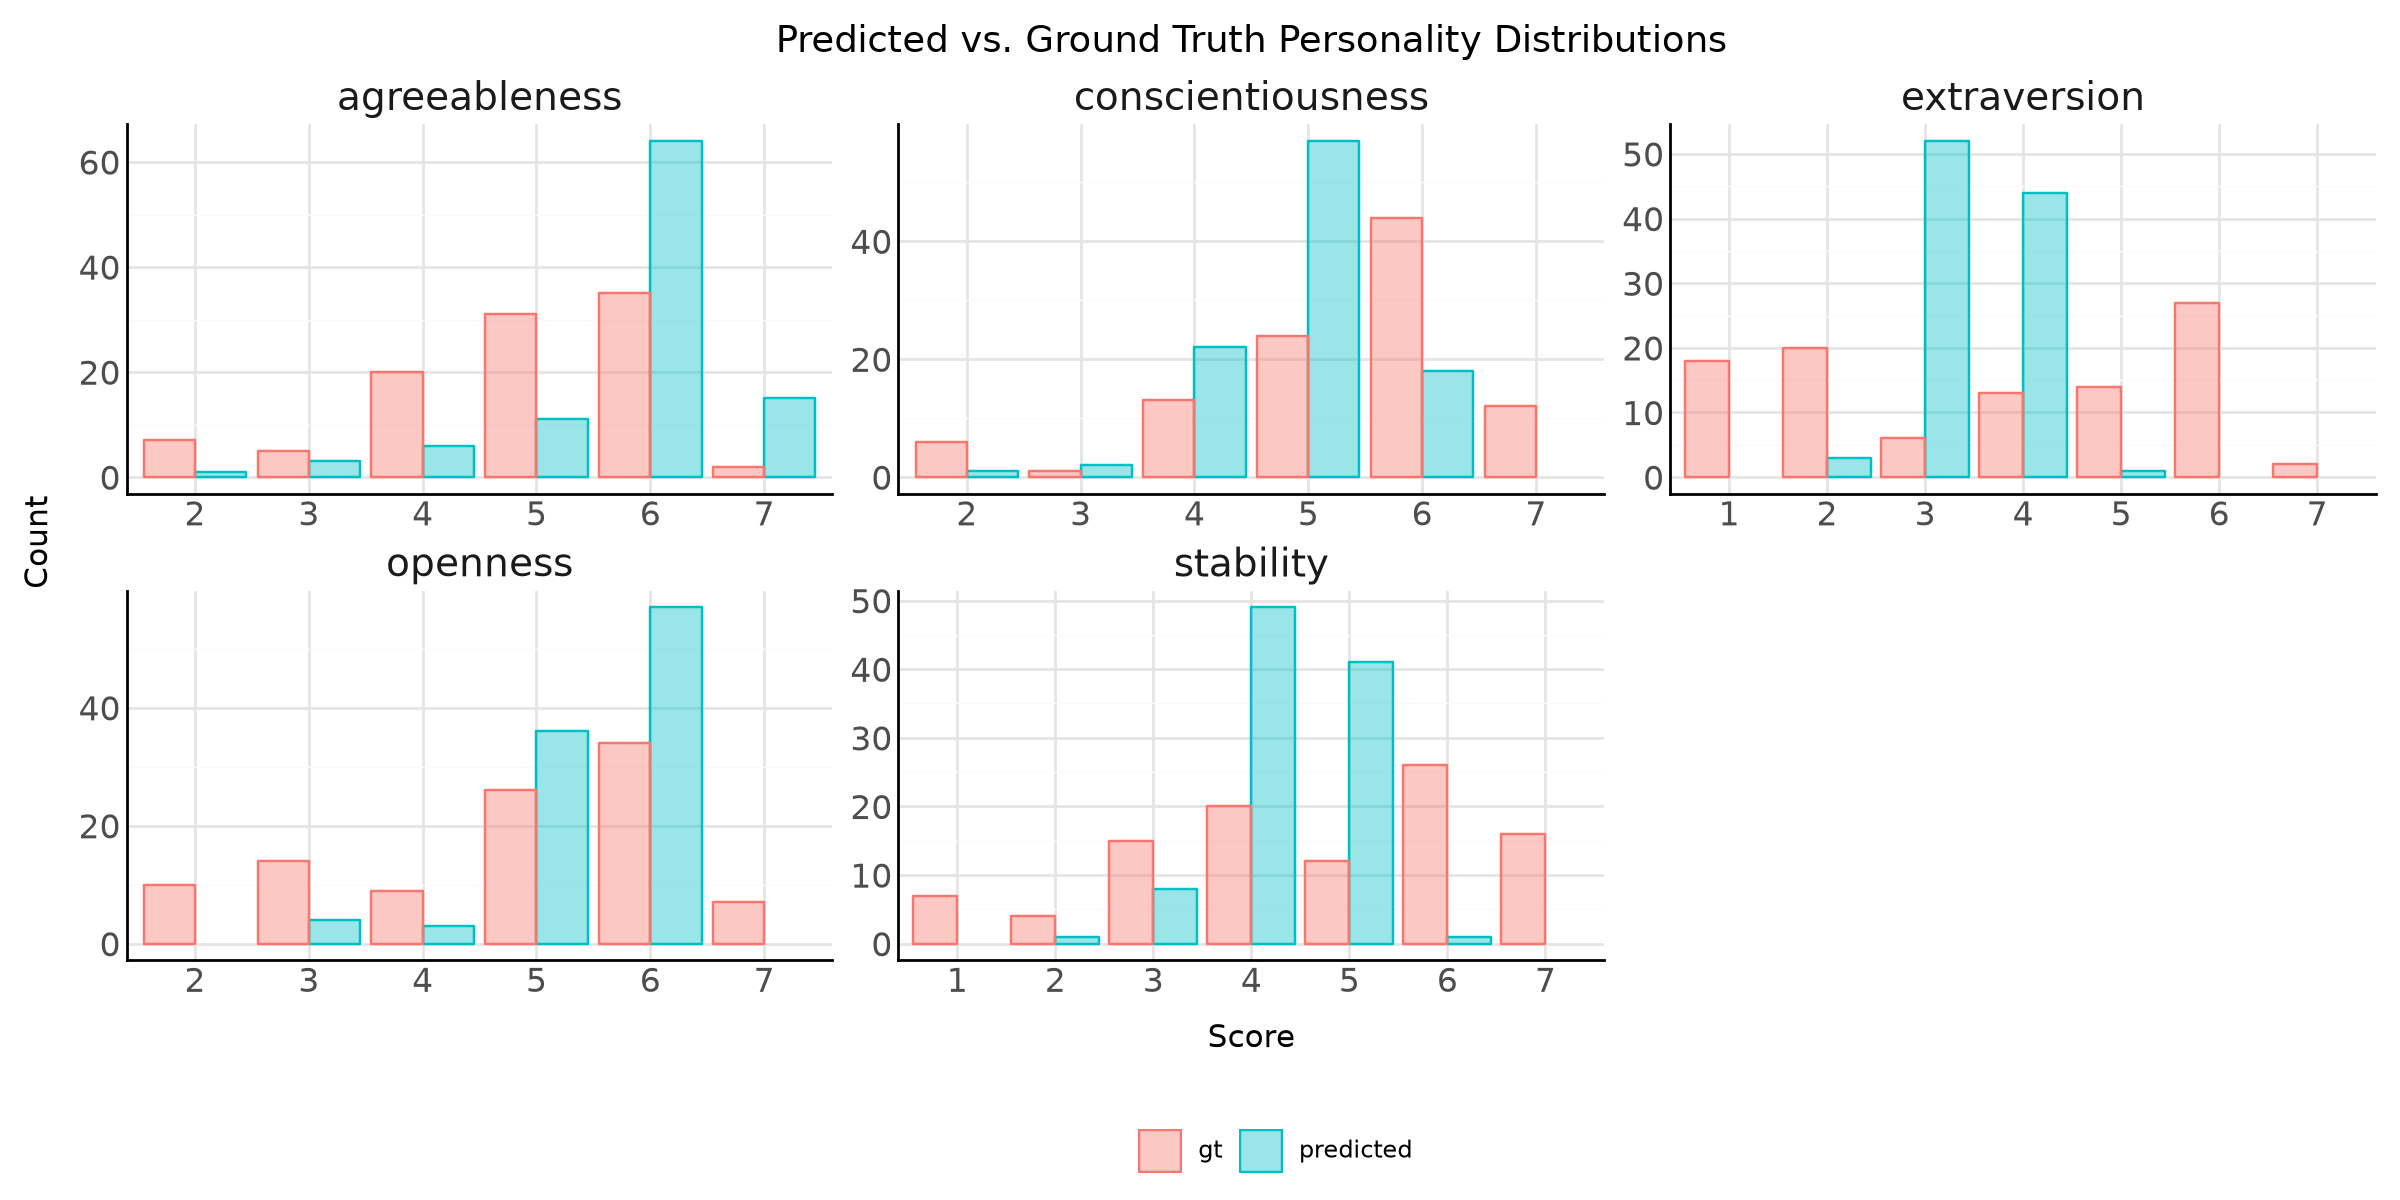

In [24]:
from scipy.stats import pearsonr

# source = "summary"
source = "in_context"

traits = ["openness", "conscientiousness", "extraversion", "agreeableness", "stability"]
predictions = pd.read_csv(f"predictions_{source}.csv")
predictions = predictions.rename(columns={f"pred_{t}": f"predicted_{t}" for t in traits})
predictions = predictions[["conversation_id", "speaker_id"] + [f"predicted_{t}" for t in traits]]

surveys = pd.read_csv("../../data/wassa2024/train/surveys.csv")
surveys = surveys.rename(columns={f"personality_{t}": f"gt_{t}" for t in traits})
surveys = surveys[["conversation_id", "person_id"] + [f"gt_{t}" for t in traits]]

comparison = pd.merge(
    predictions,
    surveys,
    left_on=["conversation_id", "speaker_id"],
    right_on=["conversation_id", "person_id"],
    how="left"
)

rows = []
for trait in traits:
    pair = comparison[[f"predicted_{trait}", f"gt_{trait}"]].dropna()
    r, p = pearsonr(pair[f"predicted_{trait}"], pair[f"gt_{trait}"])
    rows.append(
        {
            "trait": trait,
            "n": len(pair),
            "pearson_r": r,
            "p_value": p,
        }
    )

correlations = pd.DataFrame(rows)
display(correlations.round(3))

comparison = comparison.melt(
    id_vars=["conversation_id", "speaker_id"],
    value_vars=[f"predicted_{t}" for t in traits] + [f"gt_{t}" for t in traits],
    var_name="trait",
    value_name="score"
)

comparison[["source", "trait"]] = comparison["trait"].str.split("_", expand=True)
comparison["score"] = comparison["score"].astype(int)

plot_distributions(
    comparison, 
    traits, 
    title="Predicted vs. Ground Truth Personality Distributions"
)

#### OpenPersonality model

In [3]:
import pandas as pd
from scipy.stats import pearsonr
from sqlalchemy import create_engine


group_field = "speaker_id"  # the unit of prediction, one row per (conversation, speaker)

# Language-based OCEAN, one row per (group_id, trait), ridge output in `group_norm`.
engine = create_engine("mysql://ssubrahmanya@localhost/memllm?charset=utf8mb4")
query = f"SELECT * FROM `feat$p_ridg_ocean$conversations_train${group_field}`"
language = pd.read_sql(query, engine)

if group_field == "conv_speaker":
    keys = ["conversation_id", "speaker_id"]
    language[keys] = language["group_id"].str.split("_", expand=True)
    language = language.groupby(["speaker_id", "feat"]).agg({"group_norm": "mean"}).reset_index()
else:
    keys = ["speaker_id"]
    language["speaker_id"] = language["group_id"]

language = (
    language
        .pivot(
            index="speaker_id", 
            columns="feat", 
            values="group_norm"
        )
        .reset_index()
)

# Re-read surveys, since the cells above rebind it to a gt_*-renamed frame.
outcomes = pd.read_csv("../../data/wassa2024/train/surveys.csv")
columns = ["person_id"] + [f"personality_{t}" for t in ["openness", "conscientiousness", "extraversion", "agreeableness", "stability"]]
outcomes = (
    outcomes[columns]
    .groupby("person_id")
    .mean()
    .reset_index()
)

comparison = pd.merge(
    language, 
    outcomes, 
    left_on="speaker_id", 
    right_on="person_id", 
    how="inner"
)

# neu_z is neuroticism, but the survey reports emotional *stability* — its reverse —
# so a model that works gives a negative r on that row.
traits = {
    "ope_z": "personality_openness",
    "con_z": "personality_conscientiousness",
    "ext_z": "personality_extraversion",
    "agr_z": "personality_agreeableness",
    "neu_z": "personality_stability",
}

rows = []
for feat, outcome in traits.items():
    pair = comparison[[feat, outcome]].dropna()
    r, p = pearsonr(pair[feat], pair[outcome])
    rows.append(
        {
            "trait": feat, 
            "outcome": outcome, 
            "n_people": len(pair), 
            "pearson_r": r, 
            "p_value": p
        }
    )

pd.DataFrame(rows).round(3)

,trait,outcome,n_people,pearson_r,p_value
0,ope_z,personality_openness,71,-0.125,0.300
1,con_z,personality_conscientiousness,71,0.167,0.164
2,ext_z,personality_extraversion,71,0.169,0.159
3,agr_z,personality_agreeableness,71,0.194,0.104
4,neu_z,personality_stability,71,-0.118,0.325


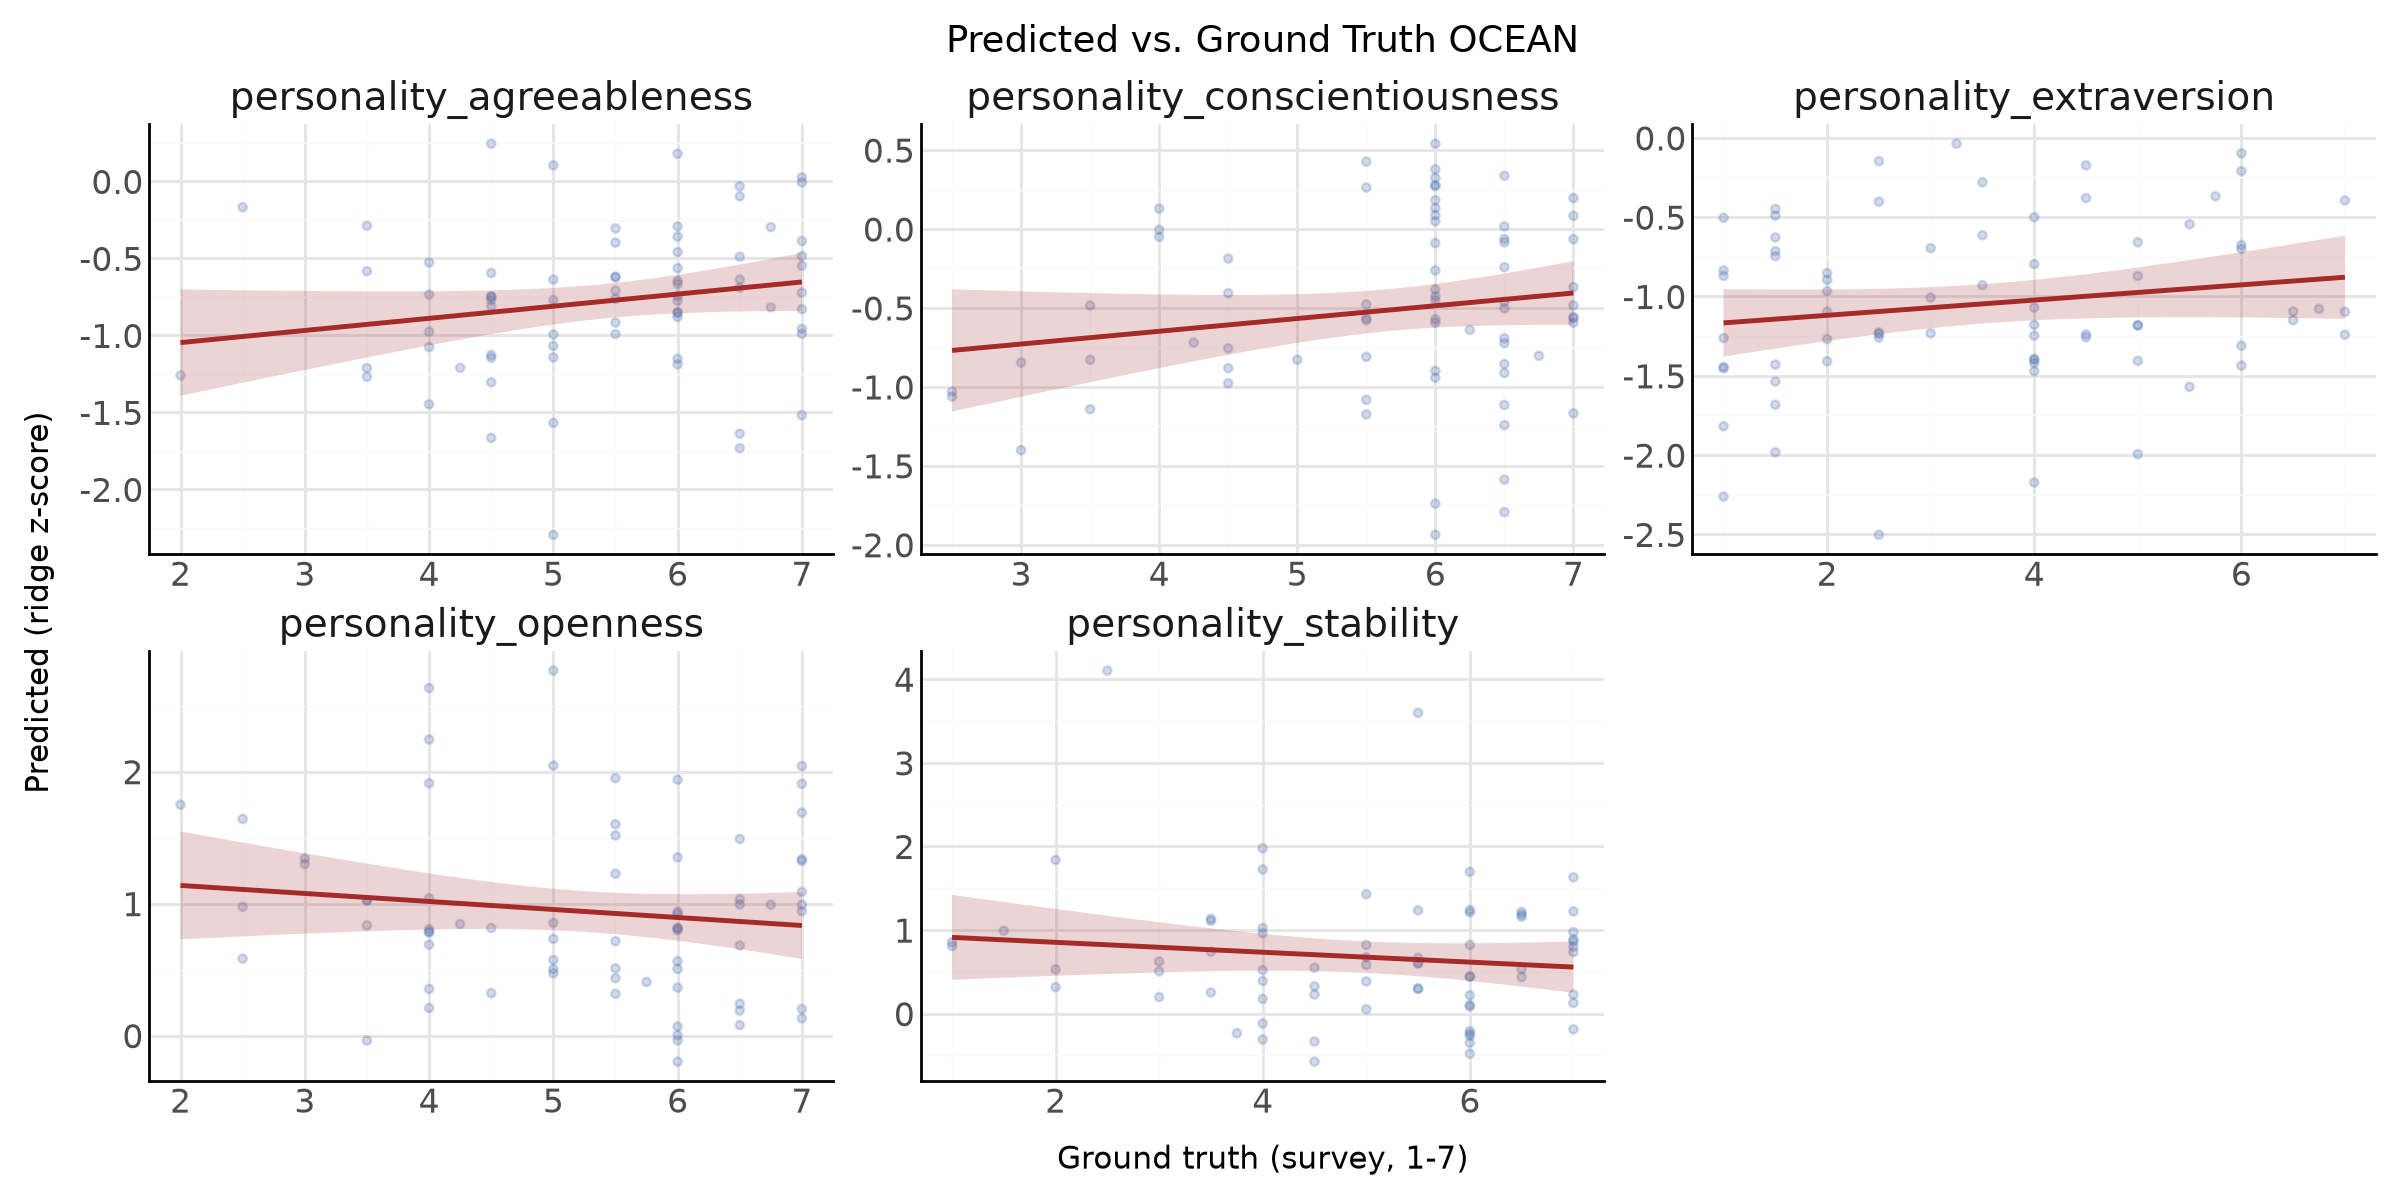

In [4]:
import plotnine as p9

comparison = comparison.melt(
    id_vars=["speaker_id"], 
    value_vars=list(traits.keys()) + list(traits.values()), 
    var_name="trait", 
    value_name="score"
)

comparison["source"] = comparison["trait"].map(lambda t: "predicted" if t in traits.keys() else "ground_truth")
comparison["trait"] = comparison["trait"].map(lambda t: traits[t] if t in traits else t)

comparison = (
    comparison
    .pivot_table(
        index=["speaker_id", "trait"], 
        columns="source", 
        values="score"
    )
    .reset_index()
)

(
    p9.ggplot(
        data=comparison,
        mapping=p9.aes(x="ground_truth", y="predicted")) +
    p9.geom_point(alpha=0.25, size=1.2, color="#4C72B0") +
    p9.geom_smooth(method="lm", color="brown", fill="brown", alpha=0.2) +
    p9.facet_wrap("trait", scales="free", ncol=3) +
    p9.labs(
        title=f"Predicted vs. Ground Truth OCEAN",
        x="Ground truth (survey, 1-7)",
        y="Predicted (ridge z-score)",
    ) +
    p9.theme_minimal() +
    p9.theme(
        figure_size=(12, 6),
        axis_line= p9.element_line(color="black"),
        axis_text= p9.element_text(size=12),
        strip_text= p9.element_text(size=14),
    )
)

In [ ]:
import pickle

import numpy as np
import pandas as pd
from sqlalchemy import create_engine

# Does the pickle's vocabulary actually appear in our conversations? The low
# correlations above could just be poor coverage — a different token distribution
# than the model was trained on.

# The OpenPersonality ridge is a DLATK pickle: `featureNamesList[0]` is the design
# matrix's 704 1-to-3 grams, `regressionModels[outcome].coef_` the aligned weights.
# It was fit under sklearn 0.20, so unpickle through DLATK's module-rename shim
# (regressionPredictor.RegressionPredictor.load).
class LegacyUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module.startswith("sklearn.linear_model"):
            module, name = "sklearn.linear_model", name.capitalize()
        elif module == "sklearn.preprocessing.data":
            module = "sklearn.preprocessing"
        return super().find_class(module, name)

with open("../../models/ocean_3dom.1to3g_ocean100.ridge10k.pickle", "rb") as f:
    model = LegacyUnpickler(f).load()

model_feats = model["featureNamesList"][0]  # 704 tokens, design-matrix order

# Distinct n-grams DLATK extracted from the conversations for this prediction unit.
engine = create_engine("mysql://ssubrahmanya@localhost/memllm?charset=utf8mb4")
dataset_feats = pd.read_sql(
    "SELECT DISTINCT feat FROM `feat$1to3gram$conversations_train$conv_speaker`", engine
)["feat"]

covered = pd.Index(model_feats).isin(dataset_feats)  # bool per model token

print(f"model tokens    : {len(model_feats)}")
print(f"dataset n-grams : {dataset_feats.nunique()}")
print(f"covered (types) : {covered.sum()} ({100 * covered.mean():.1f}%)")

# Type coverage by n-gram order (space-separated tokens). Higher orders are rarer,
# so they overlap the conversations far less than unigrams do.
ngram = pd.Series(model_feats).str.split().str.len()
coverage = (
    pd.DataFrame({"ngram": ngram, "covered": covered})
    .groupby("ngram")["covered"]
    .agg(n_model="size", n_covered="sum")
    .assign(pct_covered=lambda d: 100 * d["n_covered"] / d["n_model"])
)
display(coverage.round(1))

# A missing token is zero for every group, so after standardisation it adds the same
# constant to every prediction — it shifts the bias but leaves Pearson r untouched.
# So weight coverage by |coef|, not token count: this is the share of each outcome's
# ridge weight that actually varies across people here.
rows = []
for outcome, ridge in model["regressionModels"].items():
    weight = np.abs(np.ravel(ridge.coef_))
    rows.append(
        {
            "outcome": outcome,
            "coef_weight_covered": weight[covered].sum() / weight.sum(),
        }
    )

pd.DataFrame(rows).round(3)

#### Training prediction model

In [ ]:
import pandas as pd
from scipy.stats import pearsonr

traits = ["openness", "conscientiousness", "extraversion", "agreeableness", "stability"]

# Ignoring conv_speaker for now — its roberta-base run isn't built yet.
GROUP_FIELDS = ["speaker_id"]
MODELS = {
    "roberta-base": "big5_{group}_roberta-base_L11_ridgecv",
    "ngram": "big5_{group}_1to3gram_p0_05_ridgecv",
}

correlations = []
for group_field in GROUP_FIELDS:
    for model, stem in MODELS.items():

        run_name = stem.format(group=group_field)
        predictions = pd.read_csv(f"../../output/{run_name}.predicted_data.csv", skiprows=1)

        # The folds-mean Pearson r DLATK wrote to output/, keyed by trait.
        # The file has a Namespace() dump, a blank line, and a short header before
        # the real one carrying the metric columns — skip all three to reach it.
        folds_r = (
            pd.read_csv(f"../../output/{run_name}.accuracy_data.csv", skiprows=3)
            .assign(outcome=lambda d: d["outcome"].str.replace("personality_", "", regex=False))
            .set_index("outcome")["r_folds"]
            .to_dict()
        )

        for trait in traits:
            pair = predictions[[f"personality_{trait}__withLanguage", f"personality_{trait}_trues"]].dropna()
            # Pooled over all held-out folds, so this is out-of-sample too;
            # cv_r_folds is the mean of the same predictions taken fold by fold.
            r, p = pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])
            correlations.append(
                {
                    "group_field": group_field,
                    "model": model,
                    "trait": trait,
                    "n": len(pair),
                    "r": r,
                    "p_value": p,
                    "cv_r_folds": folds_r[trait],
                }
            )

correlations = pd.DataFrame(correlations)
display(correlations.round(4))
display(
    correlations
    .groupby(["group_field", "model"])[["r", "cv_r_folds"]]
    .mean()
    .round(3)
)
